# Lab Report "Demodulation" of Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab6_Analog_Digital_Mod).

Louis please fix this line to link to the correct folder of the repo :)

In [6]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

def loadMatlabData(path):
    """
    Loads a .mat file from the given path and returns a cleaned dictionary.

    Parameters:
        path (str): Relative or absolute path to the .mat file.

    Returns:
        dict: A dictionary containing variable names and their corresponding NumPy arrays.
    """
    raw = loadmat(path)

    # Remove MATLAB metadata keys
    cleaned = {k: v for k, v in raw.items() if not k.startswith('__')}

    # Flatten 1D arrays and ensure consistent data types
    for key, value in cleaned.items():
        if isinstance(value, np.ndarray) and value.ndim == 2 and 1 in value.shape:
            cleaned[key] = value.flatten()
        else:
            cleaned[key] = np.array(value)

    return cleaned

### Exercise 5.6 – Horn Antenna Measurements (Experiment)

- Record the radiation pattern (**Co- and Cross-polarization**) of both horn antennas in the **E-plane** and **H-plane** for **f = 11.85 GHz**.
    - Horn 1: extended in **E-plane**
    - Horn 2: extended in **H-plane**




- Print the following (not normalized) diagrams:
    1. Co- and Cross-polarization in the **E-plane** for **Horn 1** in one diagram
    2. Co- and Cross-polarization in the **H-plane** for **Horn 1** in one diagram
    3. Co- and Cross-polarization in the **E-plane** for **Horn 2** in one diagram
    4. Co- and Cross-polarization in the **H-plane** for **Horn 2** in one diagram

- Mark the **Half Power Beam Width** and the **nulls** in all diagrams (only for Co-polarization).

- Extract the following values from the 4 diagrams:
    - Half Power Beam Width (Co-polarization)
    - Cross-polarization suppression

- Compare the shape of diagrams **1** and **4**:
    - Why is there a difference, although the size of the aperture is identical?

- Compare the results (**nulls, HPBW, shape**) of diagram **1** with the theoretical calculations from **Exercise 5.4**:
    - Why are there fewer nulls?
    - Why are the nulls not as distinctive?

In [7]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Load the .mat file
data = loadMatlabData('Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/561_HornEplane_Co.mat')
mess = data['messdummy']

# Inspect the contents
print("Top-level keys:", data.keys())
print(type(mess))
print(mess.dtype)

Top-level keys: dict_keys(['messdummy'])
<class 'numpy.ndarray'>
[('type', 'O'), ('name', 'O'), ('comment', 'O'), ('startangle', 'O'), ('stopangle', 'O'), ('step', 'O'), ('velocity', 'O'), ('angles', 'O'), ('startangle_elevation', 'O'), ('stopangle_elevation', 'O'), ('step_elevation', 'O'), ('velocity_elevation', 'O'), ('angles_elevation', 'O'), ('startfreq', 'O'), ('stopfreq', 'O'), ('freqpoints', 'O'), ('freqlist', 'O'), ('IF_BW', 'O'), ('averaging', 'O'), ('parameter', 'O'), ('portpower', 'O'), ('sweepcalc', 'O'), ('sweeptime', 'O'), ('measured_data', 'O'), ('calibration', 'O'), ('calibrated_data', 'O'), ('time', 'O')]


c:\Users\luigi\OneDrive\KIT_courses\4th Semester\Microwave Engineering Lab\Microwave_Eng_Lab\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\luigi\OneDrive\KIT_courses\4th Semester\Microwave Engineering Lab\Microwave_Eng_Lab\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


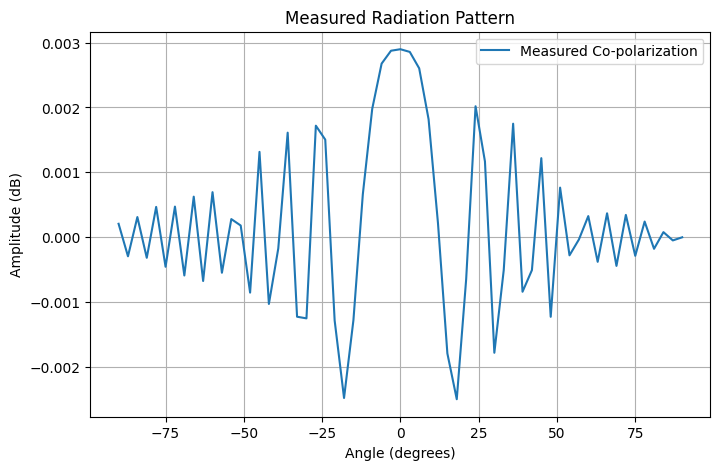

In [8]:
mess = data['messdummy'][0]  # Not [0, 0] — just one index
angles = mess['angles'].flatten()
measured_data = mess['measured_data'].flatten()
plt.figure(figsize=(8, 5))
plt.plot(angles, measured_data, label='Measured Co-polarization')
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude (dB)")
plt.title("Measured Radiation Pattern")
plt.grid(True)
plt.legend()
plt.show()